# 03c — E2 Frozen EfficientNet-B0 Training

**Experiment:** E2 — ImageNet-pretrained EfficientNet-B0 with a frozen feature extractor  
**Purpose:** Test whether transfer learning with fixed ImageNet features improves on the E1 CNN trained from scratch.

This notebook contains **training and validation only**. It does not evaluate the FaceForensics++ test set. Internal evaluation belongs in `04c_E2_FFPP_Evaluation.ipynb`.

The code was extracted from the master notebook without changing the original E2 data, preprocessing, freezing strategy, classifier, optimizer, epoch count, DataLoader settings, or output filenames.

## Experimental design

- **Research question:** Does ImageNet transfer learning with a frozen EfficientNet-B0 backbone improve performance over the CNN trained from scratch?
- **Control:** E1 Baseline CNN on full frames
- **Independent variable:** ImageNet-pretrained EfficientNet-B0 fixed feature extractor
- **Training input:** Full RGB frames from `dataset/train`
- **Validation input:** Full RGB frames from `dataset/val`
- **Preprocessing:** `EfficientNet_B0_Weights.DEFAULT.transforms()`
- **Trainable component:** Replacement two-class classifier
- **Optimizer:** Adam, classifier parameters only, learning rate 0.0001
- **Loss:** Cross-entropy
- **Epochs:** 5
- **Checkpoint:** `saved_models/efficientnet_b0.pth`

Run `00_Project_Setup.ipynb` first in a new Colab session.

## 1. Safety control

Training is disabled by default. Set it to `True` only if you intentionally want to retrain E2 and overwrite its existing checkpoint, results, and loss plot.

In [1]:
RUN_TRAINING = True
ALLOW_CHECKPOINT_OVERWRITE = False

SEED = 42
NUM_EPOCHS = 5
BATCH_SIZE = 32
LEARNING_RATE = 0.0001
NUM_WORKERS = 0

CHECKPOINT_NAME = "efficientnet_b0.pth"
RESULTS_NAME = "efficientnet_b0_results.json"
PLOT_NAME = "efficientnet_b0_training.png"

print("E2 training enabled:", RUN_TRAINING)
print("Allow checkpoint overwrite:", ALLOW_CHECKPOINT_OVERWRITE)
print("Seed:", SEED)


E2 training enabled: True
Allow checkpoint overwrite: False
Seed: 42


## 2. Imports, paths, and dataset checks

In [2]:
from google.colab import drive
drive.mount("/content/drive")

import json
import os
import random
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.models import EfficientNet_B0_Weights, efficientnet_b0

BASE_PATH = "/content/drive/MyDrive/deepfake_project"
TRAIN_DIR = os.path.join(BASE_PATH, "dataset", "train")
VAL_DIR = os.path.join(BASE_PATH, "dataset", "val")
MODEL_PATH = os.path.join(BASE_PATH, "saved_models", CHECKPOINT_NAME)
RESULTS_PATH = os.path.join(BASE_PATH, "results", RESULTS_NAME)
PLOT_PATH = os.path.join(BASE_PATH, "plots", PLOT_NAME)
SPLIT_MANIFEST_PATH = os.path.join(BASE_PATH, "ffpp_video_split_manifest.json")

for required_path, description in [
    (TRAIN_DIR, "Training directory"),
    (VAL_DIR, "Validation directory"),
    (SPLIT_MANIFEST_PATH, "Video-level split manifest"),
]:
    if not os.path.exists(required_path):
        raise FileNotFoundError(f"{description} not found: {required_path}")

if RUN_TRAINING and os.path.exists(MODEL_PATH) and not ALLOW_CHECKPOINT_OVERWRITE:
    raise FileExistsError(
        f"E2 checkpoint already exists: {MODEL_PATH}\n"
        "Set ALLOW_CHECKPOINT_OVERWRITE=True only when replacement is intentional."
    )

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: CUDA is unavailable; training will run more slowly on CPU.")
print("Training data:", TRAIN_DIR)
print("Validation data:", VAL_DIR)
print("Checkpoint:", MODEL_PATH)


Mounted at /content/drive
Device: cuda
GPU: Tesla T4
Training data: /content/drive/MyDrive/deepfake_project/dataset/train
Validation data: /content/drive/MyDrive/deepfake_project/dataset/val
Checkpoint: /content/drive/MyDrive/deepfake_project/saved_models/efficientnet_b0.pth


## 3. ImageNet preprocessing and data loaders

In [3]:
weights = EfficientNet_B0_Weights.DEFAULT
transform = weights.transforms()

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=transform)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=transform)

EXPECTED_CLASS_MAPPING = {"fake": 0, "real": 1}
if train_dataset.class_to_idx != EXPECTED_CLASS_MAPPING:
    raise ValueError(f"Unexpected training class mapping: {train_dataset.class_to_idx}")
if val_dataset.class_to_idx != EXPECTED_CLASS_MAPPING:
    raise ValueError(f"Unexpected validation class mapping: {val_dataset.class_to_idx}")

def named_class_counts(dataset):
    counts = Counter(dataset.targets)
    return {
        class_name: counts[class_index]
        for class_name, class_index in dataset.class_to_idx.items()
    }

train_class_counts = named_class_counts(train_dataset)
val_class_counts = named_class_counts(val_dataset)
if train_class_counts != {"fake": 1400, "real": 1400}:
    raise RuntimeError(f"Unexpected training counts: {train_class_counts}")
if val_class_counts != {"fake": 300, "real": 300}:
    raise RuntimeError(f"Unexpected validation counts: {val_class_counts}")

def recover_video_ids(dataset):
    identifiers = set()
    for image_path, _ in dataset.samples:
        stem = os.path.splitext(os.path.basename(image_path))[0]
        if "_frame_" not in stem:
            raise ValueError(f"Cannot recover source-video id from: {image_path}")
        identifiers.add(stem.rsplit("_frame_", 1)[0])
    return identifiers

train_video_ids = recover_video_ids(train_dataset)
val_video_ids = recover_video_ids(val_dataset)
with open(SPLIT_MANIFEST_PATH, "r", encoding="utf-8") as manifest_file:
    split_manifest = json.load(manifest_file)

expected_train_video_ids = {
    os.path.splitext(name)[0]
    for class_splits in split_manifest["classes"].values()
    for name in class_splits["train"]
}
expected_val_video_ids = {
    os.path.splitext(name)[0]
    for class_splits in split_manifest["classes"].values()
    for name in class_splits["val"]
}
if train_video_ids != expected_train_video_ids:
    raise RuntimeError("Training videos do not match the split manifest.")
if val_video_ids != expected_val_video_ids:
    raise RuntimeError("Validation videos do not match the split manifest.")

train_val_overlap = train_video_ids & val_video_ids
if train_val_overlap:
    raise RuntimeError(
        f"Train/validation video overlap: {sorted(train_val_overlap)[:5]}"
    )

loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    generator=loader_generator,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Classes:", train_dataset.classes)
print("Class mapping:", train_dataset.class_to_idx)
print("Training class counts:", train_class_counts)
print("Validation class counts:", val_class_counts)
print("Training source videos:", len(train_video_ids))
print("Validation source videos:", len(val_video_ids))
print("Train/validation overlapping videos:", len(train_val_overlap))
print("PASS: E2 data validation completed.")


Classes: ['fake', 'real']
Class mapping: {'fake': 0, 'real': 1}
Training class counts: {'fake': 1400, 'real': 1400}
Validation class counts: {'fake': 300, 'real': 300}
Training source videos: 280
Validation source videos: 60
Train/validation overlapping videos: 0
PASS: E2 data validation completed.


## 4. Build E2 and freeze the feature extractor

In [4]:
model = efficientnet_b0(weights=weights)

for parameter in model.features.parameters():
    parameter.requires_grad = False

model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
model = model.to(DEVICE)

trainable_parameters = sum(
    parameter.numel() for parameter in model.parameters() if parameter.requires_grad
)
frozen_parameters = sum(
    parameter.numel() for parameter in model.parameters() if not parameter.requires_grad
)

if not all(not p.requires_grad for p in model.features.parameters()):
    raise RuntimeError("EfficientNet feature parameters are not fully frozen.")
if not all(p.requires_grad for p in model.classifier.parameters()):
    raise RuntimeError("The replacement classifier must remain trainable.")

print(model.classifier)
print("Trainable parameters:", trainable_parameters)
print("Frozen parameters:", frozen_parameters)
print("PASS: only the E2 classifier is trainable.")


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 81.9MB/s]


Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)
Trainable parameters: 2562
Frozen parameters: 4007548
PASS: only the E2 classifier is trainable.


## 5. Train and save E2

This is the expensive cell. When `RUN_TRAINING = False`, it does not train, save, or overwrite anything.

Epoch [1/5], Loss: 0.6765, Validation Accuracy: 52.67%
Epoch [2/5], Loss: 0.6296, Validation Accuracy: 55.00%
Epoch [3/5], Loss: 0.6029, Validation Accuracy: 57.83%
Epoch [4/5], Loss: 0.5880, Validation Accuracy: 53.83%
Epoch [5/5], Loss: 0.5710, Validation Accuracy: 55.33%
Final-epoch model saved to: /content/drive/MyDrive/deepfake_project/saved_models/efficientnet_b0.pth
Results saved to: /content/drive/MyDrive/deepfake_project/results/efficientnet_b0_results.json
Best validation epoch: 3
Best validation accuracy: 57.83%


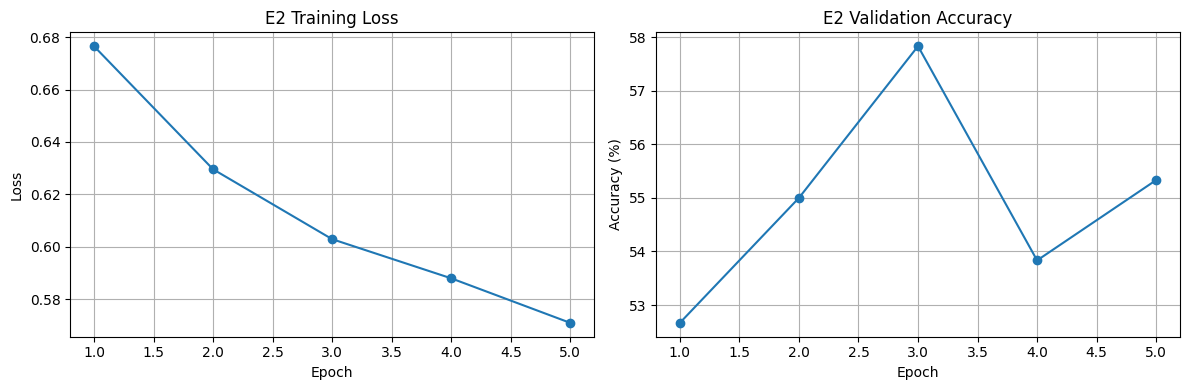

Training plot saved to: /content/drive/MyDrive/deepfake_project/plots/efficientnet_b0_training.png


In [5]:
if RUN_TRAINING:
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.classifier.parameters(), lr=LEARNING_RATE)
    train_losses = []
    val_accuracies = []

    for epoch in range(NUM_EPOCHS):
        model.train()
        # Keep frozen BatchNorm running statistics fixed as well as its weights.
        model.features.eval()
        running_loss = 0.0

        for images, labels in train_loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        average_loss = running_loss / len(train_loader)
        train_losses.append(average_loss)

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(DEVICE, non_blocking=True)
                labels = labels.to(DEVICE, non_blocking=True)
                predictions = model(images).argmax(dim=1)
                total += labels.size(0)
                correct += (predictions == labels).sum().item()

        validation_accuracy = 100.0 * correct / total
        val_accuracies.append(validation_accuracy)
        print(
            f"Epoch [{epoch + 1}/{NUM_EPOCHS}], "
            f"Loss: {average_loss:.4f}, "
            f"Validation Accuracy: {validation_accuracy:.2f}%"
        )

    best_epoch_index = int(np.argmax(val_accuracies))
    best_epoch = best_epoch_index + 1
    best_val_accuracy = val_accuracies[best_epoch_index]

    os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
    os.makedirs(os.path.dirname(RESULTS_PATH), exist_ok=True)
    os.makedirs(os.path.dirname(PLOT_PATH), exist_ok=True)
    torch.save(model.state_dict(), MODEL_PATH)
    print("Final-epoch model saved to:", MODEL_PATH)

    results = {
        "experiment": "E2",
        "research_question": "Does a frozen ImageNet EfficientNet-B0 improve on E1?",
        "model": "EfficientNet-B0",
        "training_strategy": "Frozen feature extractor and fixed BatchNorm statistics",
        "checkpoint_strategy": "final epoch",
        "transfer_learning": True,
        "pretrained_on": "ImageNet",
        "seed": SEED,
        "epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "optimizer": "Adam classifier parameters only",
        "loss_function": "CrossEntropyLoss",
        "preprocessing": "EfficientNet_B0_Weights.DEFAULT.transforms()",
        "class_mapping": train_dataset.class_to_idx,
        "training_class_counts": train_class_counts,
        "validation_class_counts": val_class_counts,
        "training_source_videos": len(train_video_ids),
        "validation_source_videos": len(val_video_ids),
        "train_validation_video_overlap": len(train_val_overlap),
        "trainable_parameters": trainable_parameters,
        "frozen_parameters": frozen_parameters,
        "training_losses": train_losses,
        "validation_accuracies": val_accuracies,
        "best_epoch": best_epoch,
        "best_val_accuracy": best_val_accuracy,
        "final_val_accuracy": val_accuracies[-1],
        "final_training_loss": train_losses[-1],
        "checkpoint_path": MODEL_PATH,
        "split_manifest_path": SPLIT_MANIFEST_PATH,
    }
    with open(RESULTS_PATH, "w", encoding="utf-8") as results_file:
        json.dump(results, results_file, indent=4)

    print("Results saved to:", RESULTS_PATH)
    print("Best validation epoch:", best_epoch)
    print(f"Best validation accuracy: {best_val_accuracy:.2f}%")

    epochs_axis = list(range(1, NUM_EPOCHS + 1))
    figure, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs_axis, train_losses, marker="o")
    axes[0].set_title("E2 Training Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True)
    axes[1].plot(epochs_axis, val_accuracies, marker="o")
    axes[1].set_title("E2 Validation Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].grid(True)
    plt.tight_layout()
    plt.savefig(PLOT_PATH, dpi=200, bbox_inches="tight")
    plt.show()
    print("Training plot saved to:", PLOT_PATH)
else:
    print("Training skipped safely.")
    print("Set RUN_TRAINING=True only when intentionally training E2.")


## 6. Next notebook

Use `04c_E2_FFPP_Evaluation.ipynb` to load `efficientnet_b0.pth` and evaluate it on the untouched FaceForensics++ test split with the same ImageNet preprocessing.

Do not use the test set to select the checkpoint, threshold, or hyperparameters.